In [2]:
!python -V

Python 3.13.9


In [1]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [8]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")

mlflow.set_experiment("trip-duration-tracking")

2026/03/17 14:53:47 INFO mlflow.tracking.fluent: Experiment with name 'trip-duration-tracking' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1773759227660, experiment_id='1', last_update_time=1773759227660, lifecycle_stage='active', name='trip-duration-tracking', tags={}, workspace='default'>

In [9]:
df = pd.read_parquet('./data/green_tripdata_2021-01.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [10]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

9.838799799829626

/tmp/ipykernel_1361/445422415.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_1361/445422415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


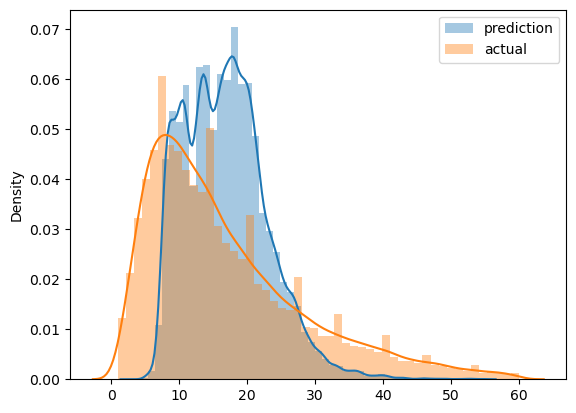

In [11]:

sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [12]:

def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [13]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')

In [14]:

len(df_train), len(df_val)

(73908, 61921)

In [15]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [16]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [17]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [18]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715202702543

In [19]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [37]:
with mlflow.start_run():

    mlflow.log_param('train-data-path', './data/green_tripdata_2021-01.parquet')
    mlflow.log_param('validation-data-path', './data/green_tripdata_2021-02.parquet')
    
    alpha = 0.01
    mlflow.log_param('alpha', alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric('rmse', rmse)

🏃 View run glamorous-sheep-313 at: http://localhost:5000/#/experiments/3/runs/2f246a86abae4bb6bf9f4f74f9dc592c
🧪 View experiment at: http://localhost:5000/#/experiments/3


In [20]:
!pip install xgboost
!pip install hyperopt

In [21]:
import xgboost as xgb

from hyperopt import fmin, hp, tpe, STATUS_OK, Trials
from hyperopt.pyll import scope

/home/sanjay/anaconda3/lib/python3.13/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [24]:
mlflow.xgboost.autolog()
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [53]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)

        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )

        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)
    return {'loss': rmse, 'status': STATUS_OK}

In [54]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|                                     | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/sanjay/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [12:45:30] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.18773                                                      
[1]	validation-rmse:6.96531                                                      
[2]	validation-rmse:6.62910                                                      
[3]	validation-rmse:6.51840                                                      
[4]	validation-rmse:6.47390                                                      
[5]	validation-rmse:6.45331                                                      
[6]	validation-rmse:6.44174                                                      
[7]	validation-rmse:6.43520                                                      
[8]	validation-rmse:6.43125                                                      
[9]	validation-rmse:6.42503                                                      
[10]	validation-rmse:6.42054                                                     
[11]	validation-rmse:6.41601                                                     
[12]	validation-

/home/sanjay/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [12:46:04] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.57787                                                     
[1]	validation-rmse:11.00598                                                     
[2]	validation-rmse:10.49225                                                     
[3]	validation-rmse:10.03268                                                     
[4]	validation-rmse:9.62089                                                      
[5]	validation-rmse:9.25331                                                      
[6]	validation-rmse:8.92560                                                      
[7]	validation-rmse:8.63416                                                      
[8]	validation-rmse:8.37570                                                      
[9]	validation-rmse:8.14776                                                      
[10]	validation-rmse:7.94557                                                     
[11]	validation-rmse:7.76750                                                     
[12]	validation-

...

[0]	validation-rmse:11.07095                                                     
[1]	validation-rmse:10.13802                                                     
[2]	validation-rmse:9.38418                                                      
[3]	validation-rmse:8.77703                                                      
[4]	validation-rmse:8.29489                                                      
[5]	validation-rmse:7.91035                                                      
[6]	validation-rmse:7.61125                                                      
[7]	validation-rmse:7.37588                                                      
[8]	validation-rmse:7.18901                                                      
[9]	validation-rmse:7.04524                                                      
[10]	validation-rmse:6.93082                                                     
[11]	validation-rmse:6.84157                                                     
[12]	validation-

/home/sanjay/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [14:19:33] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.71983                                                     
[1]	validation-rmse:11.26600                                                     
[2]	validation-rmse:10.84915                                                     
[3]	validation-rmse:10.46693                                                     
[4]	validation-rmse:10.11668                                                     
[5]	validation-rmse:9.79620                                                      
[6]	validation-rmse:9.50320                                                      
[7]	validation-rmse:9.23612                                                      
[8]	validation-rmse:8.99307                                                      
[9]	validation-rmse:8.77202                                                      
[10]	validation-rmse:8.57119                                                     
[11]	validation-rmse:8.38875                                                     
[12]	validation-

/home/sanjay/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [14:22:35] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.29370                                                     
[1]	validation-rmse:10.51191                                                     
[2]	validation-rmse:9.85021                                                      
[3]	validation-rmse:9.29245                                                      
[4]	validation-rmse:8.82526                                                      
[5]	validation-rmse:8.43790                                                      
[6]	validation-rmse:8.11489                                                      
[7]	validation-rmse:7.84760                                                      
[8]	validation-rmse:7.62838                                                      
[9]	validation-rmse:7.44575                                                      
[10]	validation-rmse:7.29626                                                     
[11]	validation-rmse:7.17246                                                     
[12]	validation-

In [25]:
params = {
    'learning_rate' : 0.17334985588145588,
    'max_depth': 33,
    'min_child_weight': 1.3533165444949402,
    'objective': 'reg:squarederror',
    'reg_alpha': 0.10081458059514621,
    'reg_lambda': 0.15437554710862098,
    'seed': 42
}


booster = xgb.train(
    params=params,
    dtrain=train,
    num_boost_round=1000,
    evals=[(valid, 'validation')],
    early_stopping_rounds=50
)



2026/03/17 15:00:47 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ea7986fe0b1c4394925d1098f445dcb5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:10.83871
[1]	validation-rmse:9.77494
[2]	validation-rmse:8.96142
[3]	validation-rmse:8.34773
[4]	validation-rmse:7.88825
[5]	validation-rmse:7.54867
[6]	validation-rmse:7.29642
[7]	validation-rmse:7.10779
[8]	validation-rmse:6.96996
[9]	validation-rmse:6.86681
[10]	validation-rmse:6.78883
[11]	validation-rmse:6.73074
[12]	validation-rmse:6.68468
[13]	validation-rmse:6.64872
[14]	validation-rmse:6.62018
[15]	validation-rmse:6.59856
[16]	validation-rmse:6.58099
[17]	validation-rmse:6.56590
[18]	validation-rmse:6.55297
[19]	validation-rmse:6.54402
[20]	validation-rmse:6.53652
[21]	validation-rmse:6.52923
[22]	validation-rmse:6.52239
[23]	validation-rmse:6.51815
[24]	validation-rmse:6.51499
[25]	validation-rmse:6.51135
[26]	validation-rmse:6.50951
[27]	validation-rmse:6.50795
[28]	validation-rmse:6.50704
[29]	validation-rmse:6.50538
[30]	validation-rmse:6.50383
[31]	validation-rmse:6.50222
[32]	validation-rmse:6.50093
[33]	validation-rmse:6.49981
[34]	validation-rmse:6.

2026/03/17 15:02:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run clumsy-bird-970 at: http://localhost:5000/#/experiments/1/runs/ea7986fe0b1c4394925d1098f445dcb5
🧪 View experiment at: http://localhost:5000/#/experiments/1
